# **HOUSE PRICE PREDICTION**

In [2039]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.ensemble import RandomForestRegressor



# **READING CSV FILE**

In [2040]:
df=pd.read_csv('train.csv')

In [2041]:
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [2042]:
df.columns

Index(['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig',
       'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType',
       'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd',
       'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType',
       'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1',
       'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual',
       'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType',
       'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual',
       'GarageCond', 'PavedDrive

In [2043]:
df=df.drop(columns=["Id"])

In [2044]:
df.head()

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


# **DATA PREPROCESSING**

# HANDLING NULL VALUES

In [2132]:
#check for null values in each features
df.isnull().sum().sort_values(ascending=False)


,0
MSSubClass,0
LotFrontage,0
LotArea,0
OverallQual,0
OverallCond,0
...,...
SaleCondition_AdjLand,0
SaleCondition_Alloca,0
SaleCondition_Family,0
SaleCondition_Normal,0


In [2046]:
df["PoolQC"]

,PoolQC
0,NaN
1,NaN
2,NaN
3,NaN
4,NaN
...,...
1455,NaN
1456,NaN
1457,NaN
1458,NaN


In [2047]:
df["PoolQC"]= df["PoolQC"].fillna("No Pool")

In [2048]:
 df["PoolQC"].isnull()

,PoolQC
0,False
1,False
2,False
3,False
4,False
...,...
1455,False
1456,False
1457,False
1458,False


In [2049]:
df["Alley"]=df["Alley"].fillna("No Alley")

In [2050]:
df

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,60,RL,65.0,8450,Pave,No Alley,Reg,Lvl,AllPub,Inside,...,0,No Pool,NaN,NaN,0,2,2008,WD,Normal,208500
1,20,RL,80.0,9600,Pave,No Alley,Reg,Lvl,AllPub,FR2,...,0,No Pool,NaN,NaN,0,5,2007,WD,Normal,181500
2,60,RL,68.0,11250,Pave,No Alley,IR1,Lvl,AllPub,Inside,...,0,No Pool,NaN,NaN,0,9,2008,WD,Normal,223500
3,70,RL,60.0,9550,Pave,No Alley,IR1,Lvl,AllPub,Corner,...,0,No Pool,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,60,RL,84.0,14260,Pave,No Alley,IR1,Lvl,AllPub,FR2,...,0,No Pool,NaN,NaN,0,12,2008,WD,Normal,250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,60,RL,62.0,7917,Pave,No Alley,Reg,Lvl,AllPub,Inside,...,0,No Pool,NaN,NaN,0,8,2007,WD,Normal,175000
1456,20,RL,85.0,13175,Pave,No Alley,Reg,Lvl,AllPub,Inside,...,0,No Pool,MnPrv,NaN,0,2,2010,WD,Normal,210000
1457,70,RL,66.0,9042,Pave,No Alley,Reg,Lvl,AllPub,Inside,...,0,No Pool,GdPrv,Shed,2500,5,2010,WD,Normal,266500
1458,20,RL,68.0,9717,Pave,No Alley,Reg,Lvl,AllPub,Inside,...,0,No Pool,NaN,NaN,0,4,2010,WD,Normal,142125


In [2051]:
df["BsmtCond"]=df["BsmtCond"].fillna("No Basement")

In [2052]:
print(df["BsmtCond"].isnull().sum())

0


In [2053]:
df["BsmtExposure"]=df["BsmtExposure"].fillna("No Basement")

In [2054]:
df["BsmtQual"] = df["BsmtQual"].fillna("No Basement")

In [2055]:
df["BsmtFinType1"]=df["BsmtFinType1"].fillna("No Basement")

In [2056]:
df["BsmtFinType2"]=df["BsmtFinType2"].fillna("No Basement")

In [2057]:
df["BsmtFinType2"].isnull().sum()

np.int64(0)

In [2058]:
df["FireplaceQu"]=df["FireplaceQu"].fillna("No Fireplace")

In [2059]:
df["GarageType"]=df["GarageType"].fillna("No Garage")
df["GarageFinish"]=df["GarageFinish"].fillna("No Garage")
df["GarageQual"]=df["GarageQual"].fillna("No Garage")
df["GarageCond"]=df["GarageCond"].fillna("No Garage")

In [2060]:
df["Fence"]=df["Fence"].fillna("No Fence")

In [2061]:
df["MiscFeature"]=df["MiscFeature"].fillna("None")

In [2062]:
print(df.isnull().sum())

MSSubClass         0
MSZoning           0
LotFrontage      259
LotArea            0
Street             0
                ... 
MoSold             0
YrSold             0
SaleType           0
SaleCondition      0
SalePrice          0
Length: 80, dtype: int64


In [2063]:
df["LotFrontage"]

,LotFrontage
0,65.0
1,80.0
2,68.0
3,60.0
4,84.0
...,...
1455,62.0
1456,85.0
1457,66.0
1458,68.0


In [2064]:
df["LotFrontage"] = df["LotFrontage"].fillna(df["LotFrontage"].median())

In [2065]:
df["LotFrontage"].isnull().sum()

np.int64(0)

In [2066]:
df.isnull().sum()

,0
MSSubClass,0
MSZoning,0
LotFrontage,0
LotArea,0
Street,0
...,...
MoSold,0
YrSold,0
SaleType,0
SaleCondition,0


# ENCODE STRINGS

In [2067]:
df["OverallCond"]

,OverallCond
0,5
1,8
2,5
3,5
4,5
...,...
1455,5
1456,6
1457,9
1458,6


In [2068]:
#Encode strings since model cannot understand string data
#Label encoder for ordinal data
#one hot encoder for ordinal
qual1={"Po":1,"Fa":2,"TA":3,"Gd":4,"Ex":5}

In [2069]:
df["ExterQual"] = df["ExterQual"].map(qual1)

In [2070]:
df["ExterCond"] = df["ExterCond"].map(qual1)

In [2071]:
df["ExterCond"]

,ExterCond
0,3
1,3
2,3
3,3
4,3
...,...
1455,3
1456,3
1457,4
1458,3


In [2072]:
qual2={"No Basement":0,"Po":1,"Fa":2,"TA":3,"Gd":4,"Ex":5}

In [2073]:
df["BsmtQual"] = df["BsmtQual"].map(qual2)

In [2074]:
exposure_map = {
    "No Basement":0,
    "No": 1,
    "Mn": 2,
    "Av": 3,
    "Gd": 4
}

In [2075]:
df["BsmtExposure"]=df["BsmtExposure"].map(exposure_map)

In [2076]:
fin_rate={"No Basement":0,"Unf":1,"LwQ":2,"Rec":3,"BLQ":4,"ALQ":5,"GLQ":6}

In [2077]:
df["BsmtFinType1"]=df["BsmtFinType1"].map(fin_rate)

In [2078]:
df["BsmtFinType2"]=df["BsmtFinType2"].map(fin_rate)

In [2079]:
print(df["BsmtFinType2"].unique())

[1 4 0 5 3 2 6]


In [2080]:
qual3={"No Fireplace":0,"Po":1,"Fa":2,"TA":3,"Gd":4,"Ex":5}

In [2081]:
df["HeatingQC"]=df["HeatingQC"].map(qual1)

In [2082]:
df["KitchenQual"]=df["KitchenQual"].map(qual1)

In [2083]:
df["FireplaceQu"]=df["FireplaceQu"].map(qual3)

In [2084]:
qual4={"No Garage":0,"Po":1,"Fa":2,"TA":3,"Gd":4,"Ex":5}

In [2085]:
df["GarageQual"]=df["GarageQual"].map(qual4)

In [2086]:
df["GarageCond"]=df["GarageCond"].map(qual4)

In [2087]:
qual5={"No Pool":0,"Po":1,"Fa":2,"TA":3,"Gd":4,"Ex":5}

In [2088]:
df["PoolQC"]=df["PoolQC"].map(qual5)

In [2089]:
df = pd.get_dummies(df, drop_first=True)

In [2090]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Columns: 219 entries, MSSubClass to SaleCondition_Partial
dtypes: bool(170), float64(3), int64(46)
memory usage: 801.4 KB


In [2091]:
print(df.columns[70:150])

Index(['Neighborhood_BrDale', 'Neighborhood_BrkSide', 'Neighborhood_ClearCr',
       'Neighborhood_CollgCr', 'Neighborhood_Crawfor', 'Neighborhood_Edwards',
       'Neighborhood_Gilbert', 'Neighborhood_IDOTRR', 'Neighborhood_MeadowV',
       'Neighborhood_Mitchel', 'Neighborhood_NAmes', 'Neighborhood_NPkVill',
       'Neighborhood_NWAmes', 'Neighborhood_NoRidge', 'Neighborhood_NridgHt',
       'Neighborhood_OldTown', 'Neighborhood_SWISU', 'Neighborhood_Sawyer',
       'Neighborhood_SawyerW', 'Neighborhood_Somerst', 'Neighborhood_StoneBr',
       'Neighborhood_Timber', 'Neighborhood_Veenker', 'Condition1_Feedr',
       'Condition1_Norm', 'Condition1_PosA', 'Condition1_PosN',
       'Condition1_RRAe', 'Condition1_RRAn', 'Condition1_RRNe',
       'Condition1_RRNn', 'Condition2_Feedr', 'Condition2_Norm',
       'Condition2_PosA', 'Condition2_PosN', 'Condition2_RRAe',
       'Condition2_RRAn', 'Condition2_RRNn', 'BldgType_2fmCon',
       'BldgType_Duplex', 'BldgType_Twnhs', 'BldgType_TwnhsE

In [2092]:
df.isnull().sum().sort_values(ascending=False)

,0
GarageYrBlt,81
MasVnrArea,8
LotFrontage,0
LotArea,0
OverallQual,0
...,...
SaleCondition_AdjLand,0
SaleCondition_Alloca,0
SaleCondition_Family,0
SaleCondition_Normal,0


In [2093]:
df["GarageYrBlt"] = df["GarageYrBlt"].fillna(0)

In [2094]:
df.isnull().sum().sort_values(ascending=False)

,0
MasVnrArea,8
LotFrontage,0
MSSubClass,0
LotArea,0
OverallQual,0
...,...
SaleCondition_AdjLand,0
SaleCondition_Alloca,0
SaleCondition_Family,0
SaleCondition_Normal,0


In [2095]:
df["MasVnrArea"] = df["MasVnrArea"].fillna(0)

In [2096]:
df.isnull().sum().sort_values(ascending=False)

,0
MSSubClass,0
LotFrontage,0
LotArea,0
OverallQual,0
OverallCond,0
...,...
SaleCondition_AdjLand,0
SaleCondition_Alloca,0
SaleCondition_Family,0
SaleCondition_Normal,0


In [2097]:
#Convert the boolean values to a normal int to get proper 0 or 1 values
df = df.astype(int)

In [2098]:
df

,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,ExterQual,ExterCond,...,SaleType_ConLI,SaleType_ConLw,SaleType_New,SaleType_Oth,SaleType_WD,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial
0,60,65,8450,7,5,2003,2003,196,4,3,...,0,0,0,0,1,0,0,0,1,0
1,20,80,9600,6,8,1976,1976,0,3,3,...,0,0,0,0,1,0,0,0,1,0
2,60,68,11250,7,5,2001,2002,162,4,3,...,0,0,0,0,1,0,0,0,1,0
3,70,60,9550,7,5,1915,1970,0,3,3,...,0,0,0,0,1,0,0,0,0,0
4,60,84,14260,8,5,2000,2000,350,4,3,...,0,0,0,0,1,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,60,62,7917,6,5,1999,2000,0,3,3,...,0,0,0,0,1,0,0,0,1,0
1456,20,85,13175,6,6,1978,1988,119,3,3,...,0,0,0,0,1,0,0,0,1,0
1457,70,66,9042,7,9,1941,2006,0,5,4,...,0,0,0,0,1,0,0,0,1,0
1458,20,68,9717,5,6,1950,1996,0,3,3,...,0,0,0,0,1,0,0,0,1,0


# **SPLIT DATA**

In [2099]:
x=df.drop(columns=["SalePrice"])
y=df["SalePrice"]

In [2100]:
x

,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,ExterQual,ExterCond,...,SaleType_ConLI,SaleType_ConLw,SaleType_New,SaleType_Oth,SaleType_WD,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial
0,60,65,8450,7,5,2003,2003,196,4,3,...,0,0,0,0,1,0,0,0,1,0
1,20,80,9600,6,8,1976,1976,0,3,3,...,0,0,0,0,1,0,0,0,1,0
2,60,68,11250,7,5,2001,2002,162,4,3,...,0,0,0,0,1,0,0,0,1,0
3,70,60,9550,7,5,1915,1970,0,3,3,...,0,0,0,0,1,0,0,0,0,0
4,60,84,14260,8,5,2000,2000,350,4,3,...,0,0,0,0,1,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,60,62,7917,6,5,1999,2000,0,3,3,...,0,0,0,0,1,0,0,0,1,0
1456,20,85,13175,6,6,1978,1988,119,3,3,...,0,0,0,0,1,0,0,0,1,0
1457,70,66,9042,7,9,1941,2006,0,5,4,...,0,0,0,0,1,0,0,0,1,0
1458,20,68,9717,5,6,1950,1996,0,3,3,...,0,0,0,0,1,0,0,0,1,0


In [2101]:
x_original=x

In [2102]:
y

,SalePrice
0,208500
1,181500
2,223500
3,140000
4,250000
...,...
1455,175000
1456,210000
1457,266500
1458,142125


In [2103]:
y_original=y

In [2104]:

#we do this to deal with right skewedness of the data
y = np.log1p(y)

In [2105]:
#we split the data into testing and training sets
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

# **NORMALISATION**

In [2106]:
scaler=StandardScaler()

In [2107]:
#We normalise the value so the model wont be overwhelmed with large values by (x-mean)/std
x_train=scaler.fit_transform(x_train)
x_test=scaler.transform(x_test)

# **TENSOR CONVERSION**

In [2108]:
#Conver y and x to tensors for neural network
x_train=torch.tensor(x_train,dtype=torch.float32)

In [2109]:
x_train.shape

torch.Size([1168, 218])

In [2110]:
x_test=torch.tensor(x_test,dtype=torch.float32)

In [2111]:
x_test.shape

torch.Size([292, 218])

In [2112]:
y_train=torch.tensor(y_train.values,dtype=torch.float32)

In [2113]:
y_train=y_train.view(-1,1)

In [2114]:
y_train.shape

torch.Size([1168, 1])

In [2115]:
y_test=torch.tensor(y_test.values,dtype=torch.float32)
y_test=y_test.view(-1,1)
y_test.shape

torch.Size([292, 1])

# **MODEL CREATION**

# **1.NEURAL NETWORK**

In [2116]:
#create the neural network model since this a dataset with a huge amount of data we handle the dimensionality issue by adding dropout
class ModelPrice(nn.Module):
  def __init__(self,input_features,hidden_features,hidden2,output_features):
    super().__init__()
    self.linear1=nn.Linear(in_features=input_features,out_features=hidden_features)
    self.relu1=nn.ReLU()
    self.dropout = nn.Dropout(0.3)
    self.linear2=nn.Linear(in_features=hidden_features,out_features=hidden2)
    self.relu2=nn.ReLU()
    self.linear3=nn.Linear(in_features=hidden2,out_features=output_features)
  def forward(self,x):
      x=self.linear1(x)
      x=self.relu1(x)
      x = self.dropout(x)
      x=self.linear2(x)
      x=self.relu2(x)
      x = self.dropout(x)
      x=self.linear3(x)
      return x



In [2117]:
model=ModelPrice(x_train.shape[1],64,32,1)

In [2118]:
loss_fn=nn.MSELoss()

In [2119]:
optimizer=optim.Adam(model.parameters(),lr=0.001)

In [2120]:
#training loop
epochs=150
for epoch in range(epochs):
  output=model(x_train)
  loss=loss_fn(output,y_train)
  optimizer.zero_grad()
  loss.backward()
  optimizer.step()
  if epoch%10==0:
      print(f"Epoch:{epoch} Loss:{loss}")

Epoch:0 Loss:145.3856964111328
Epoch:10 Loss:137.3548583984375
Epoch:20 Loss:122.9301528930664
Epoch:30 Loss:97.57810974121094
Epoch:40 Loss:62.082725524902344
Epoch:50 Loss:27.977420806884766
Epoch:60 Loss:18.30744743347168
Epoch:70 Loss:12.93327808380127
Epoch:80 Loss:10.393219947814941
Epoch:90 Loss:9.834630966186523
Epoch:100 Loss:8.78742504119873
Epoch:110 Loss:7.877852916717529
Epoch:120 Loss:7.6577935218811035
Epoch:130 Loss:7.589709758758545
Epoch:140 Loss:6.851442813873291


# **NEURAL NETWORK EVALUATION**

In [2121]:
#evaluating the model
model.eval()

with torch.no_grad():
    test_pred = model(x_test)
    test_loss = loss_fn(test_pred, y_test)


print(test_loss.item())
nn_loss=test_loss.item()

2.619290351867676


# **RANDOM FOREST MODEL**

In [2122]:
#create a new training set for these ML models
x_train_orig, x_test_orig, y_train_orig, y_test_orig = train_test_split(
    x_original, y_original, test_size=0.2, random_state=42
)

In [2123]:
y_train_log = np.log1p(y_train_orig)
y_test_log = np.log1p(y_test_orig)

In [2124]:
model = RandomForestRegressor(n_estimators=500, random_state=42)
model.fit(x_train_orig, y_train_log)

pred = model.predict(x_test_orig)

In [2125]:
rf_rmse = np.sqrt(mean_squared_error(y_test, pred))
print(rf_rmse)

0.14733950242849697


# **XGBOOST MODEL**

In [2126]:
from xgboost import XGBRegressor


model = XGBRegressor(
    n_estimators=1000,
    learning_rate=0.03,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1,
    random_state=42
)

model.fit(
    x_train_orig, y_train_log,
    eval_set=[(x_test_orig, y_test_log)]
)
val_pred =model.predict(pd.DataFrame(x_test, columns=x_original.columns))
val_pred = model.predict(x_test_orig)

XGB_rmse = np.sqrt(mean_squared_error(y_test_log, val_pred))
print("RMSE:", XGB_rmse)

[0]	validation_0-rmse:0.42355
[1]	validation_0-rmse:0.41442
[2]	validation_0-rmse:0.40575
[3]	validation_0-rmse:0.39795
[4]	validation_0-rmse:0.38981
[5]	validation_0-rmse:0.38153
[6]	validation_0-rmse:0.37351
[7]	validation_0-rmse:0.36611
[8]	validation_0-rmse:0.35922
[9]	validation_0-rmse:0.35207
[10]	validation_0-rmse:0.34556
[11]	validation_0-rmse:0.33923
[12]	validation_0-rmse:0.33293
[13]	validation_0-rmse:0.32658
[14]	validation_0-rmse:0.32039
[15]	validation_0-rmse:0.31389
[16]	validation_0-rmse:0.30827
[17]	validation_0-rmse:0.30266
[18]	validation_0-rmse:0.29747
[19]	validation_0-rmse:0.29206
[20]	validation_0-rmse:0.28717
[21]	validation_0-rmse:0.28214
[22]	validation_0-rmse:0.27750
[23]	validation_0-rmse:0.27276
[24]	validation_0-rmse:0.26840
[25]	validation_0-rmse:0.26399
[26]	validation_0-rmse:0.26002
[27]	validation_0-rmse:0.25629
[28]	validation_0-rmse:0.25270
[29]	validation_0-rmse:0.24877
[30]	validation_0-rmse:0.24544
[31]	validation_0-rmse:0.24209
[32]	validation_0-

In [2127]:
print("NN Loss:", test_loss.item())
print("rf_RMSE:", rf_rmse)
print("XGB_RMSE:", XGB_rmse)

NN Loss: 2.619290351867676
rf_RMSE: 0.14733950242849697
XGB_RMSE: 0.13145059143419938


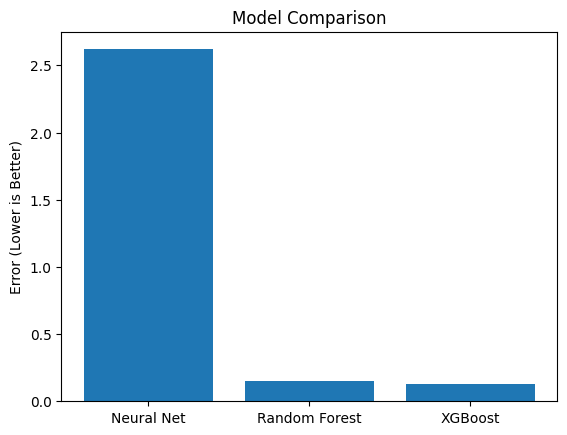

In [2128]:

models = ["Neural Net", "Random Forest", "XGBoost"]
scores = [nn_loss, rf_rmse, XGB_rmse]
plt.bar(models, scores)
plt.title("Model Comparison")
plt.ylabel("Error (Lower is Better)")
plt.show()



*   XGBoost performed best due to handling high-dimensional tabular data better.
*  Tree-based models outperform neural networks on tabular data due to their ability to handle feature interactions and sparsity.





# **KAGGLE TEST DATA CLEANING**

In [2129]:
#load the test data
test_df = pd.read_csv("test.csv")
test_ids = test_df["Id"]
test_df = test_df.drop(columns=["Id"])

In [2130]:
#clean the test data
test_df = pd.read_csv("test.csv")

test_ids = test_df["Id"]
test_df = test_df.drop(columns=["Id"])


test_df["PoolQC"] = test_df["PoolQC"].fillna("No Pool")
test_df["Alley"] = test_df["Alley"].fillna("No Alley")

test_df["BsmtQual"] = test_df["BsmtQual"].fillna("No Basement")
test_df["BsmtCond"] = test_df["BsmtCond"].fillna("No Basement")
test_df["BsmtExposure"] = test_df["BsmtExposure"].fillna("No Basement")
test_df["BsmtFinType1"] = test_df["BsmtFinType1"].fillna("No Basement")
test_df["BsmtFinType2"] = test_df["BsmtFinType2"].fillna("No Basement")

test_df["FireplaceQu"] = test_df["FireplaceQu"].fillna("No Fireplace")

test_df["GarageType"] = test_df["GarageType"].fillna("No Garage")
test_df["GarageFinish"] = test_df["GarageFinish"].fillna("No Garage")
test_df["GarageQual"] = test_df["GarageQual"].fillna("No Garage")
test_df["GarageCond"] = test_df["GarageCond"].fillna("No Garage")

test_df["Fence"] = test_df["Fence"].fillna("No Fence")
test_df["MiscFeature"] = test_df["MiscFeature"].fillna("None")


test_df["LotFrontage"] = test_df["LotFrontage"].fillna(test_df["LotFrontage"].median())
test_df["GarageYrBlt"] = test_df["GarageYrBlt"].fillna(0)
test_df["MasVnrArea"] = test_df["MasVnrArea"].fillna(0)

qual1 = {"Po":1,"Fa":2,"TA":3,"Gd":4,"Ex":5}
qual2 = {"No Basement":0,"Po":1,"Fa":2,"TA":3,"Gd":4,"Ex":5}
qual3 = {"No Fireplace":0,"Po":1,"Fa":2,"TA":3,"Gd":4,"Ex":5}
qual4 = {"No Garage":0,"Po":1,"Fa":2,"TA":3,"Gd":4,"Ex":5}
qual5 = {"No Pool":0,"Po":1,"Fa":2,"TA":3,"Gd":4,"Ex":5}

exposure_map = {"No Basement":0,"No":1,"Mn":2,"Av":3,"Gd":4}
fin_map = {"No Basement":0,"Unf":1,"LwQ":2,"Rec":3,"BLQ":4,"ALQ":5,"GLQ":6}

test_df["ExterQual"] = test_df["ExterQual"].map(qual1)
test_df["ExterCond"] = test_df["ExterCond"].map(qual1)
test_df["HeatingQC"] = test_df["HeatingQC"].map(qual1)
test_df["KitchenQual"] = test_df["KitchenQual"].map(qual1)

test_df["BsmtQual"] = test_df["BsmtQual"].map(qual2)
test_df["BsmtCond"] = test_df["BsmtCond"].map(qual2)

test_df["BsmtExposure"] = test_df["BsmtExposure"].map(exposure_map)
test_df["BsmtFinType1"] = test_df["BsmtFinType1"].map(fin_map)
test_df["BsmtFinType2"] = test_df["BsmtFinType2"].map(fin_map)

test_df["FireplaceQu"] = test_df["FireplaceQu"].map(qual3)
test_df["GarageQual"] = test_df["GarageQual"].map(qual4)
test_df["GarageCond"] = test_df["GarageCond"].map(qual4)

test_df["PoolQC"] = test_df["PoolQC"].map(qual5)

test_df = pd.get_dummies(test_df, drop_first=True)


test_df = test_df.reindex(columns=x.columns, fill_value=0)



# **MODEL SELECTION AND PREDICTION :XGBOOST**

In [2131]:
from xgboost import XGBRegressor


model = XGBRegressor(
    n_estimators=1000,
    learning_rate=0.03,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1,
    random_state=42
)

model.fit(
    x_train_orig, y_train_log,
    eval_set=[(x_test_orig, y_test_log)]
)
val_pred =model.predict(pd.DataFrame(x_test, columns=x_original.columns))
val_pred = model.predict(x_test_orig)

rmse = np.sqrt(mean_squared_error(y_test_log, val_pred))
print("RMSE:", rmse)

pred = model.predict(test_df)

pred = np.expm1(pred)

submission = pd.DataFrame({
    "Id": test_ids,
    "SalePrice": pred
})

submission.to_csv("submission.csv", index=False)

[0]	validation_0-rmse:0.42355
[1]	validation_0-rmse:0.41442
[2]	validation_0-rmse:0.40575
[3]	validation_0-rmse:0.39795
[4]	validation_0-rmse:0.38981
[5]	validation_0-rmse:0.38153
[6]	validation_0-rmse:0.37351
[7]	validation_0-rmse:0.36611
[8]	validation_0-rmse:0.35922
[9]	validation_0-rmse:0.35207
[10]	validation_0-rmse:0.34556
[11]	validation_0-rmse:0.33923
[12]	validation_0-rmse:0.33293
[13]	validation_0-rmse:0.32658
[14]	validation_0-rmse:0.32039
[15]	validation_0-rmse:0.31389
[16]	validation_0-rmse:0.30827
[17]	validation_0-rmse:0.30266
[18]	validation_0-rmse:0.29747
[19]	validation_0-rmse:0.29206
[20]	validation_0-rmse:0.28717
[21]	validation_0-rmse:0.28214
[22]	validation_0-rmse:0.27750
[23]	validation_0-rmse:0.27276
[24]	validation_0-rmse:0.26840
[25]	validation_0-rmse:0.26399
[26]	validation_0-rmse:0.26002
[27]	validation_0-rmse:0.25629
[28]	validation_0-rmse:0.25270
[29]	validation_0-rmse:0.24877
[30]	validation_0-rmse:0.24544
[31]	validation_0-rmse:0.24209
[32]	validation_0-